In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "4) house Prediction Data Set.csv",
    header=None,
    sep=r",\s*|\s+",
    engine="python"
)

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [10]:
df = pd.read_csv("4) house Prediction Data Set.csv", sep=",")
df.head()

,0.00632 18.00 2.310 0 0.5380 6.5750 65.20 4.0900 1 296.0 15.30 396.90 4.98 24.00
0,0.02731 0.00 7.070 0 0.4690 6.4210 78...
1,0.02729 0.00 7.070 0 0.4690 7.1850 61...
2,0.03237 0.00 2.180 0 0.4580 6.9980 45...
3,0.06905 0.00 2.180 0 0.4580 7.1470 54...
4,0.02985 0.00 2.180 0 0.4580 6.4300 58...


In [14]:
print(df.shape)

(506, 14)


In [15]:
df.columns = [
    "CRIM",
    "ZN",
    "INDUS",
    "CHAS",
    "NOX",
    "RM",
    "AGE",
    "DIS",
    "RAD",
    "TAX",
    "PTRATIO",
    "B",
    "LSTAT",
    "PRICE"
]

In [16]:
df = df.iloc[1:].reset_index(drop=True)

In [17]:
df = df.apply(pd.to_numeric)

In [18]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
1,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
2,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
3,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
4,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21,28.7


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     505 non-null    float64
 1   ZN       505 non-null    float64
 2   INDUS    505 non-null    float64
 3   CHAS     505 non-null    int64  
 4   NOX      505 non-null    float64
 5   RM       505 non-null    float64
 6   AGE      505 non-null    float64
 7   DIS      505 non-null    float64
 8   RAD      505 non-null    int64  
 9   TAX      505 non-null    float64
 10  PTRATIO  505 non-null    float64
 11  B        505 non-null    float64
 12  LSTAT    505 non-null    float64
 13  PRICE    505 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.4 KB


In [20]:
df.shape

(505, 14)

The dataset contains 505 observations and 14 columns. The target variable is PRICE, while the remaining 13 columns are predictor variables describing different characteristics of houses.

In [21]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000
mean,3.620667,11.350495,11.154257,0.069307,0.554728,6.284059,68.581584,3.794459,9.566337,408.459406,18.461782,356.594376,12.668257,22.529901
std,8.608572,23.343704,6.855868,0.254227,0.115990,0.703195,28.176371,2.107757,8.707553,168.629992,2.162520,91.367787,7.139950,9.205991
min,0.009060,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082210,0.000000,5.190000,0.000000,0.449000,5.885000,45.000000,2.100000,4.000000,279.000000,17.400000,375.330000,7.010000,17.000000
50%,0.259150,0.000000,9.690000,0.000000,0.538000,6.208000,77.700000,3.199200,5.000000,330.000000,19.100000,391.430000,11.380000,21.200000
75%,3.678220,12.500000,18.100000,0.000000,0.624000,6.625000,94.100000,5.211900,24.000000,666.000000,20.200000,396.210000,16.960000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


The statistical summary provides information such as the mean, standard deviation, minimum, maximum, and quartiles for each numerical feature. This helps understand the distribution of the dataset.

In [22]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


The dataset contains no missing values, so no imputation or removal of missing data is required.

In [23]:
df.duplicated().sum()

np.int64(0)

There are no duplicate records in the dataset.

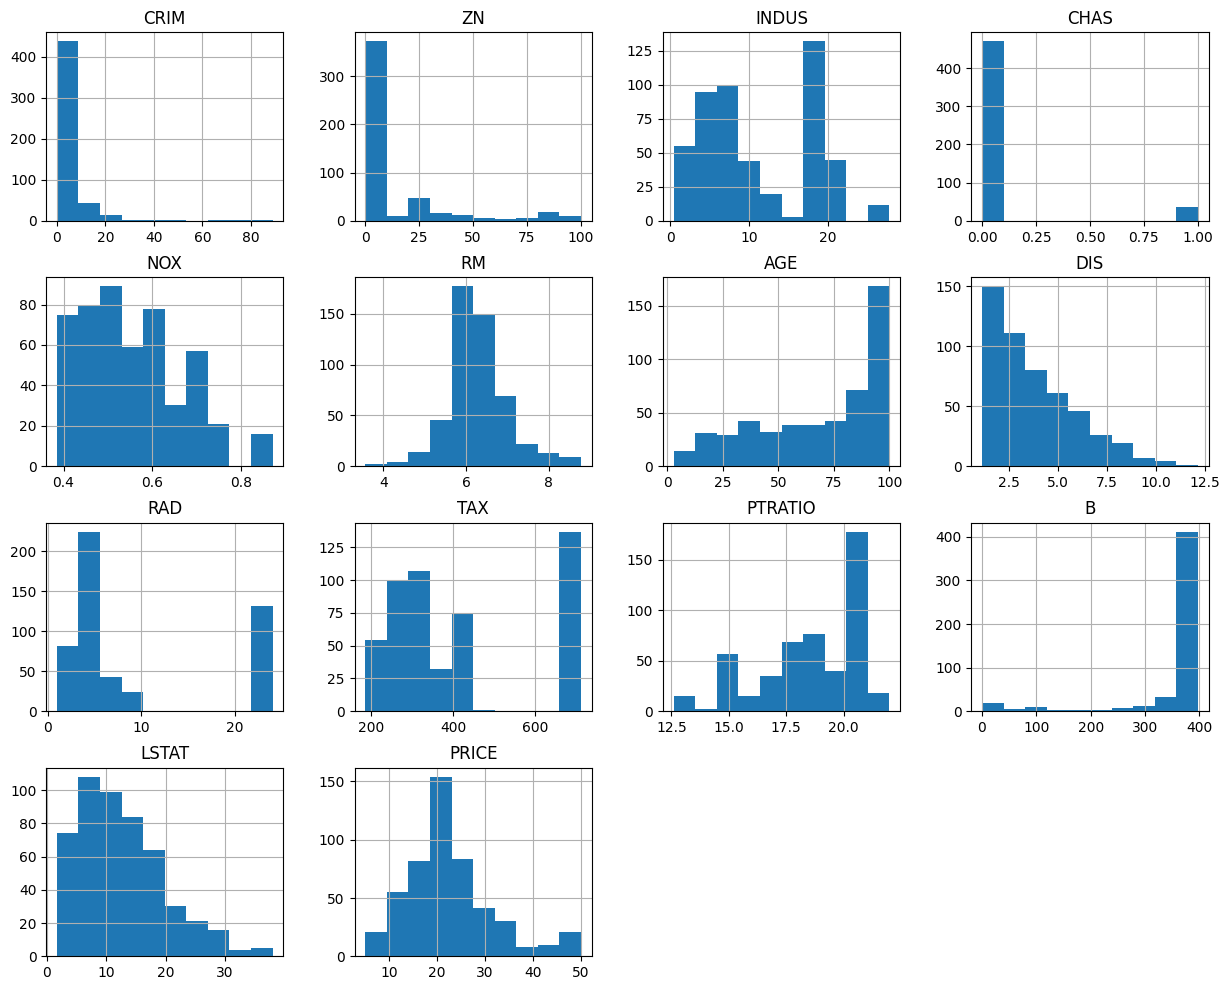

In [24]:
df.hist(figsize=(15,12))
plt.show()

Histograms are used to visualize the distribution of each numerical feature.

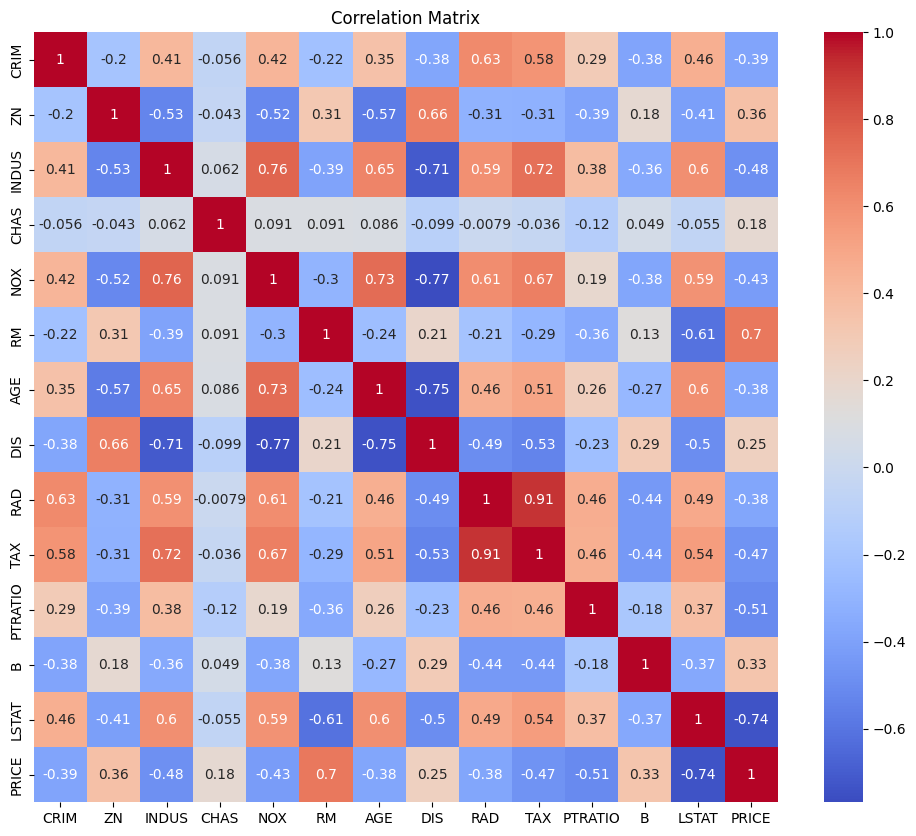

In [25]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

The heatmap shows the correlation between variables. Features with high positive or negative correlation may strongly influence house prices.

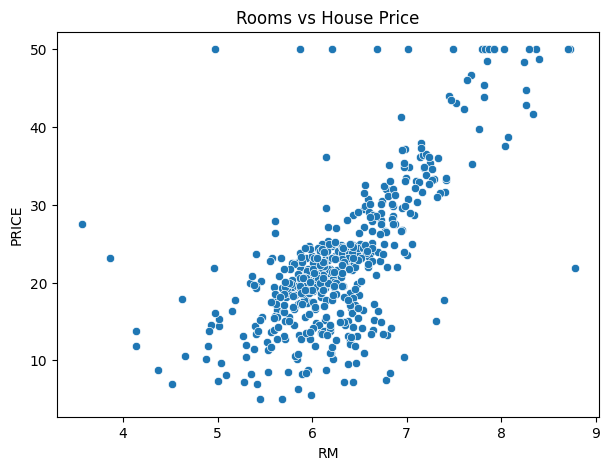

In [26]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="RM", y="PRICE", data=df)
plt.title("Rooms vs House Price")
plt.show()

Houses with a larger average number of rooms generally have higher prices.

In [27]:
X = df.drop("PRICE", axis=1)
y = df["PRICE"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

The dataset was split into 80% training data and 20% testing data to evaluate the model on unseen data.

In [29]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [30]:
y_pred = model.predict(X_test)

y_pred[:10]

array([26.87187901, 33.95259383, 14.27729131, 23.98322578, 35.95742085,
       23.59338056, 11.45119102,  3.49825392, 23.50367023, 20.74508931])

This show the first 10 predicted house prices.

In [31]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Squared Error: 19.379041116137028
Root Mean Squared Error: 4.402163231428047
R² Score: 0.652220188866615


In [32]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
173,22.6,26.871879
274,32.0,33.952594
490,13.6,14.277291
72,23.4,23.983226
305,33.4,35.957421
76,20.8,23.593381
476,12.0,11.451191
140,14.4,3.498254
470,19.6,23.503670
499,16.8,20.745089


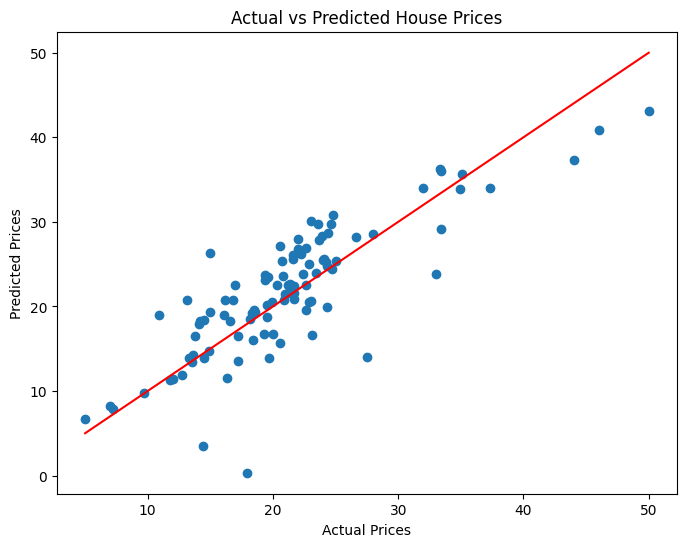

In [33]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

In [34]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [36]:
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Results")
print("MSE:", dt_mse)
print("RMSE:", dt_rmse)
print("R²:", dt_r2)

Decision Tree Results
MSE: 20.856732673267327
RMSE: 4.566917195797108
R²: 0.6257012663062911


In [37]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [38]:
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest Results
MSE: 7.579063217821782
RMSE: 2.7530098470259388
R²: 0.8639847473017042


In [39]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MSE": [
        mse,
        dt_mse,
        rf_mse
    ],
    "RMSE": [
        rmse,
        dt_rmse,
        rf_rmse
    ],
    "R² Score": [
        r2,
        dt_r2,
        rf_r2
    ]
})

results

,Model,MSE,RMSE,R² Score
0,Linear Regression,19.379041,4.402163,0.652220
1,Decision Tree,20.856733,4.566917,0.625701
2,Random Forest,7.579063,2.753010,0.863985


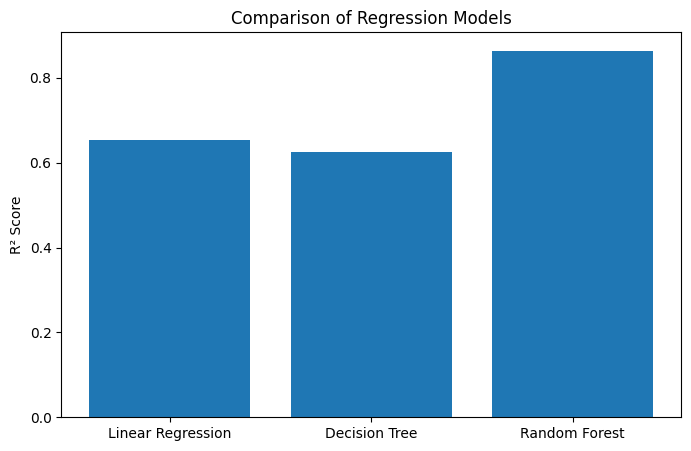

In [40]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R² Score"])

plt.title("Comparison of Regression Models")
plt.ylabel("R² Score")

plt.show()

Three regression algorithms were implemented and evaluated on the Boston Housing dataset: Linear Regression, Decision Tree Regressor, and Random Forest Regressor. The models were compared using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. The Random Forest Regressor achieved the best performance with the lowest prediction error (RMSE = 2.753) and the highest R² Score (0.864), indicating that it explains approximately 86.4% of the variance in house prices. Therefore, Random Forest is the most suitable model for this regression task.

In [41]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
5,RM,0.420365
12,LSTAT,0.391711
7,DIS,0.064164
0,CRIM,0.039440
9,TAX,0.017036
6,AGE,0.015097
4,NOX,0.014749
11,B,0.012866
10,PTRATIO,0.012658
2,INDUS,0.005013


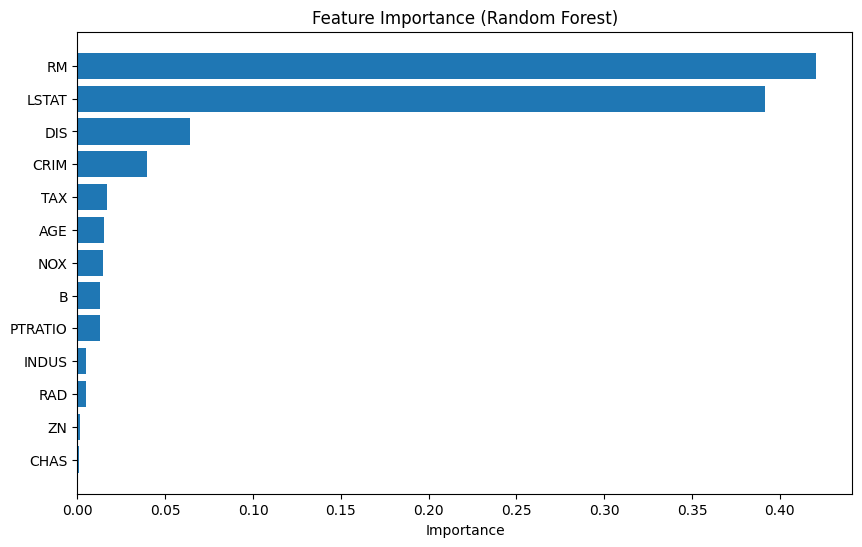

In [42]:
plt.figure(figsize=(10,6))

plt.barh(importance["Feature"], importance["Importance"])

plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()

plt.show()

In this project, three regression models were developed and evaluated to predict house prices. Linear Regression, Decision Tree Regressor, and Random Forest Regressor were compared using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. Among the three models, the Random Forest Regressor achieved the best performance with an R² Score of 0.864, an RMSE of 2.753, and the lowest MSE of 7.579. These results indicate that Random Forest captures the relationships in the data more effectively than the other models and is the most suitable model for predicting house prices in this dataset.